In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "functions"))

In [2]:
from signal_processing import load_raw_gdf, rename_and_montage, bandpass_filter, run_ica, apply_ica, epoch_raw, compute_tfr, get_motor_events
from dataset import log_normalize

import matplotlib.pyplot as plt
import mne

# Data Loading and Visualization

In [3]:
gdf_path = Path.cwd().parent / "data" / "BCICIV_2a_gdf" / "A01T.gdf"
raw = load_raw_gdf(gdf_path, [22, 23, 24])

Extracting GDF parameters from /Users/ashvath/eeg-wheelchair-control/data/BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/opt/anaconda3/envs/ckd_env/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [4]:
rename_and_montage(raw)

Using matplotlib as 2D backend.


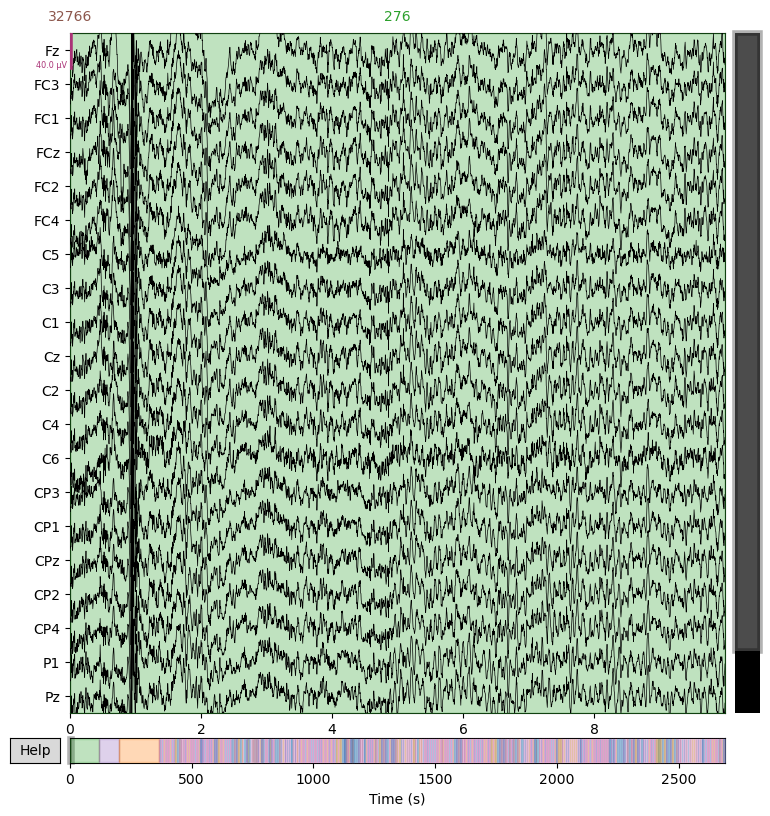

In [5]:
_ = raw.plot()

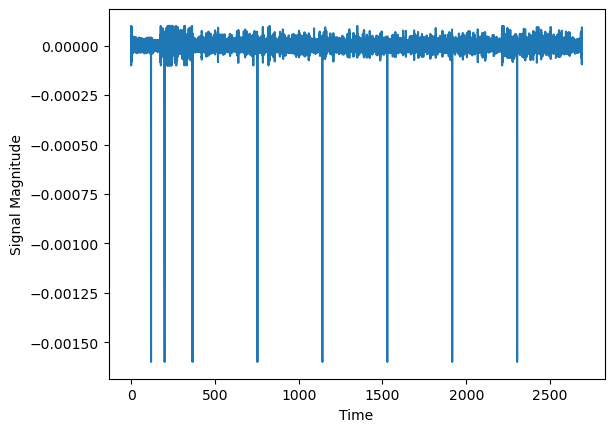

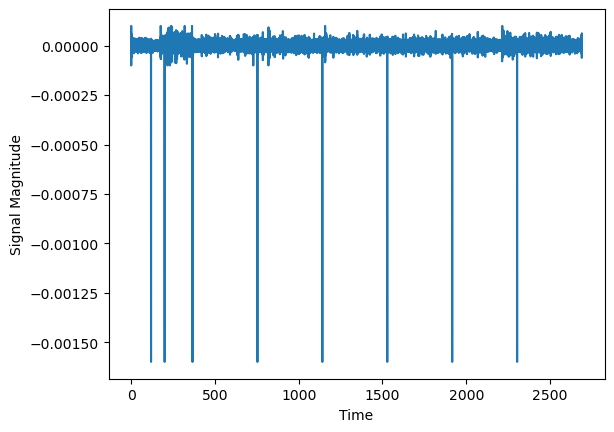

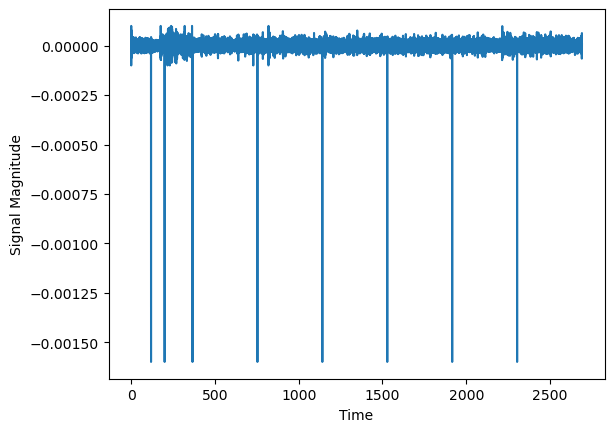

In [6]:
ch_idx = [0,1,2]
data = raw.get_data(picks=ch_idx)
time = raw.times
for index in ch_idx: 
    plt.plot(time, data[index])
    plt.xlabel("Time")
    plt.ylabel("Signal Magnitude")
    plt.show()

# Bandpass Filter

In [7]:
bandpass_filter(raw, 3, 35, True)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB



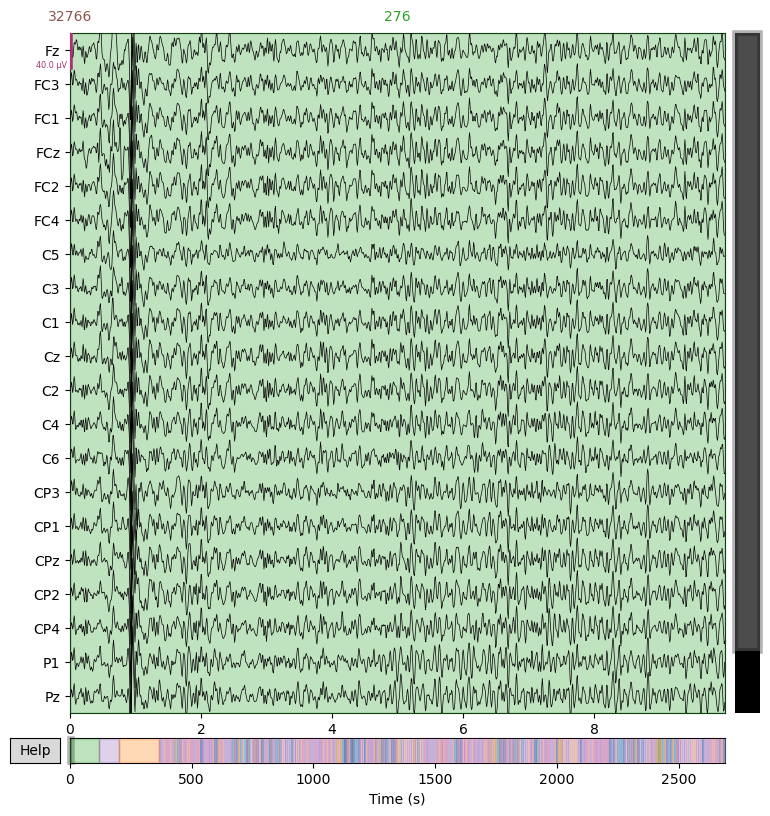

In [8]:
_ = raw.plot()

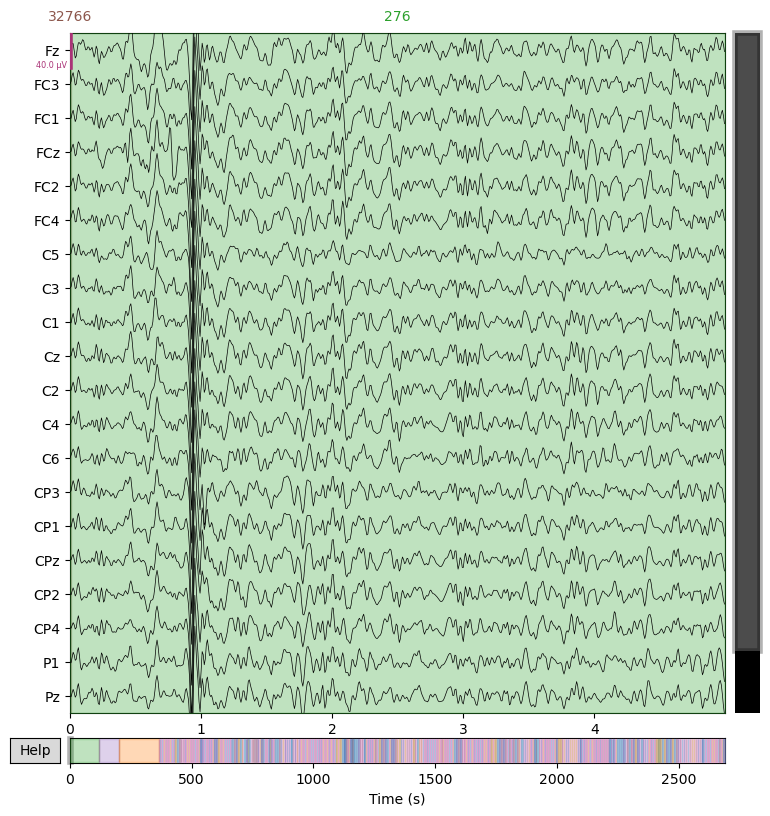

In [13]:
_ = raw.plot(duration=5, start=0)

# Butterworth ICA (IIR) 

In [9]:
ica = run_ica(raw, 20)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 6.9s.


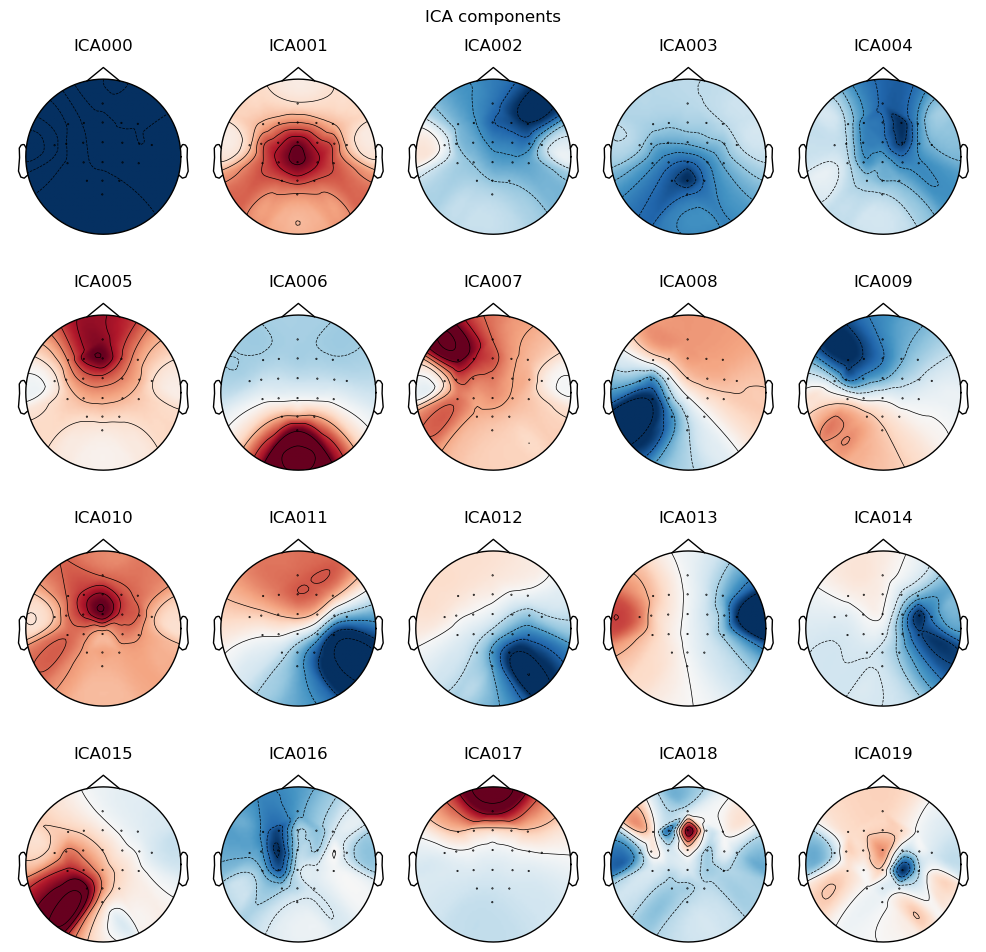

In [10]:
_ = ica.plot_components()

Creating RawArray with float64 data, n_channels=20, n_times=672528
    Range : 0 ... 672527 =      0.000 ...  2690.108 secs
Ready.


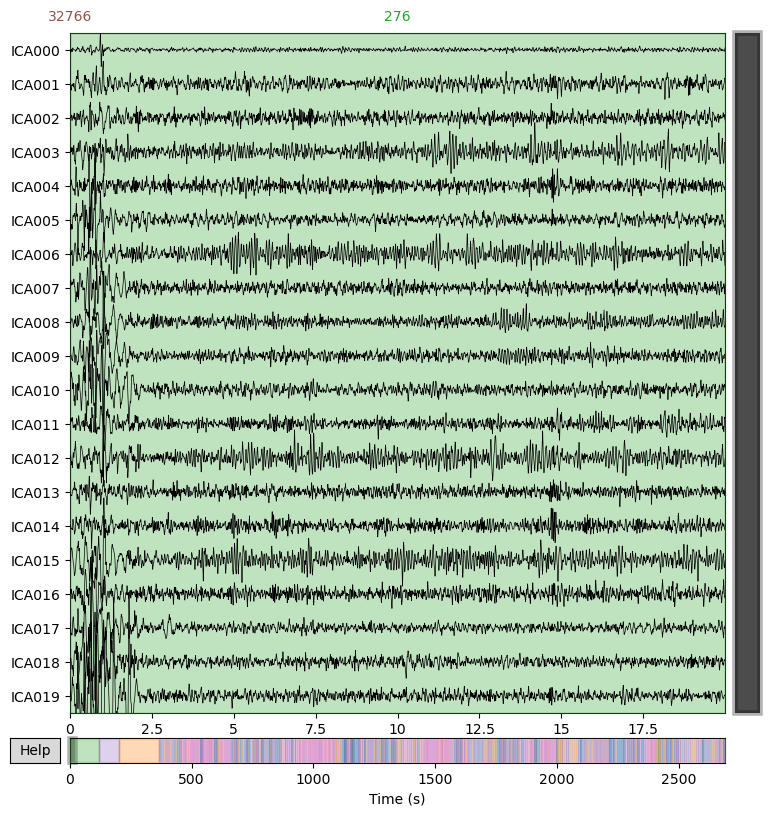

In [11]:
_ = ica.plot_sources(raw)

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
1345 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1345 matching events found
No baseline correction applied
0 projection items activated


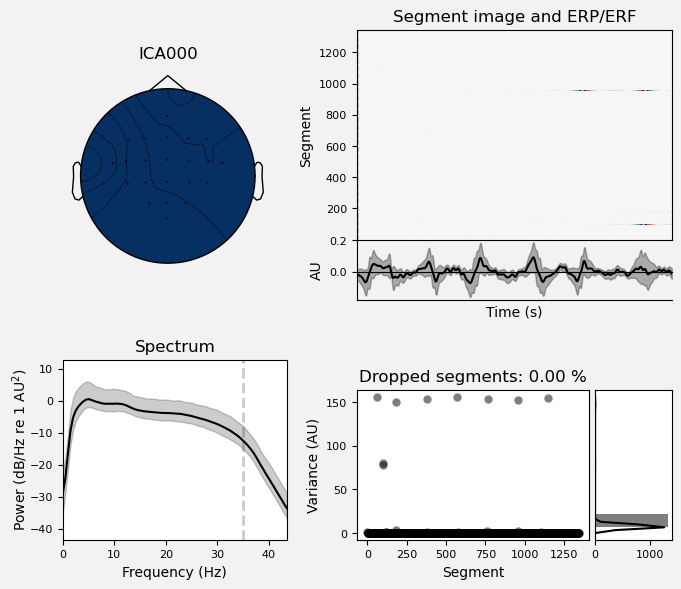

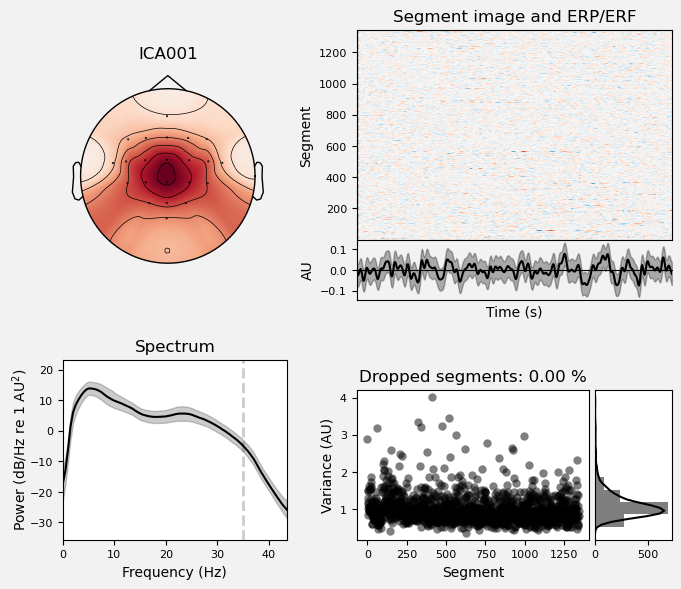

In [14]:
_ = ica.plot_properties(raw, picks=[0, 1])

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
1345 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1345 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1345 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1345 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1345 matching events found
No baseline correction applied
0 projection items activated


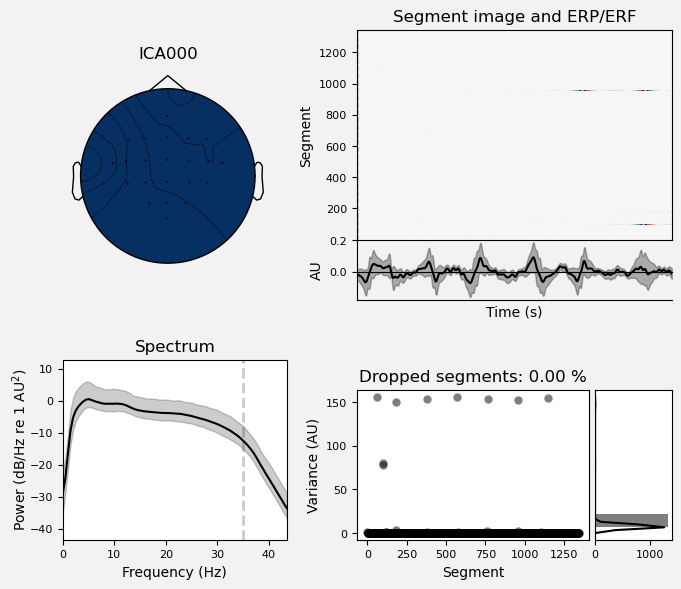

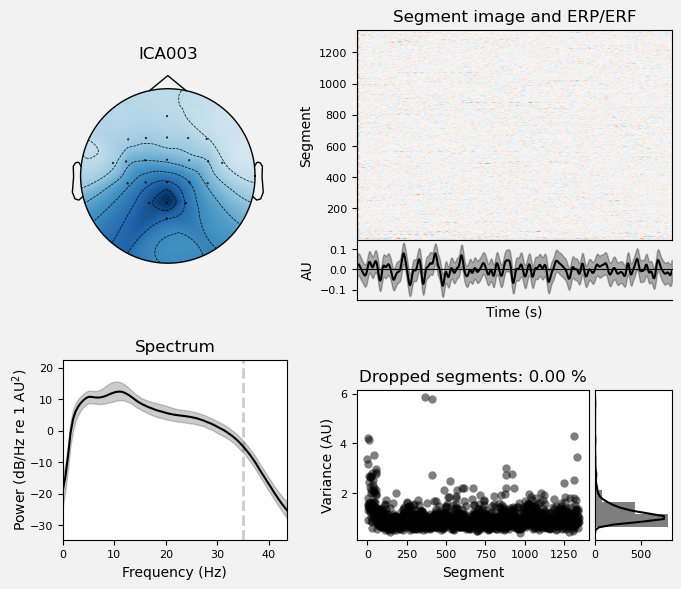

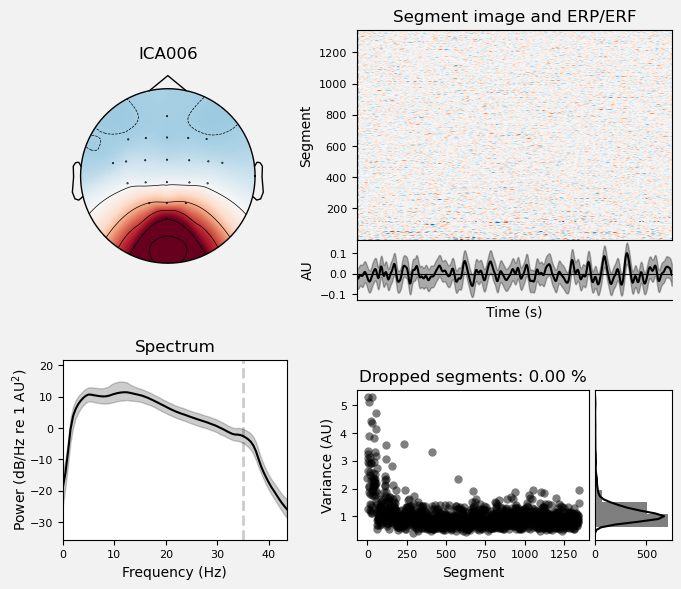

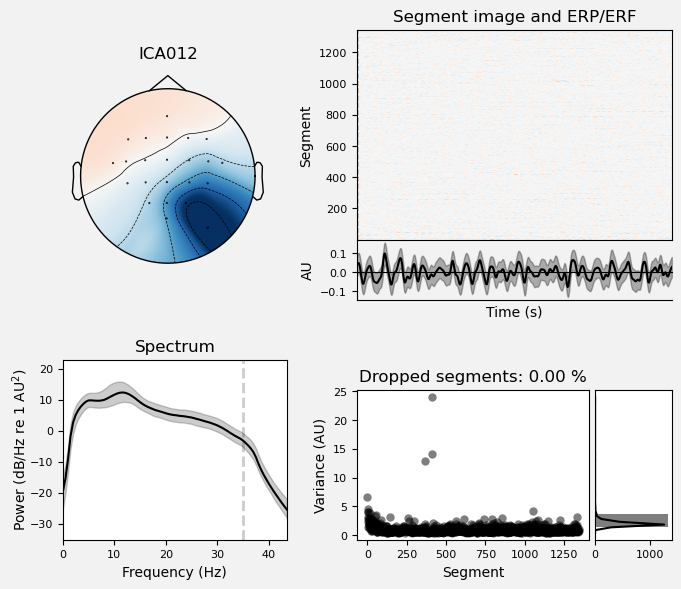

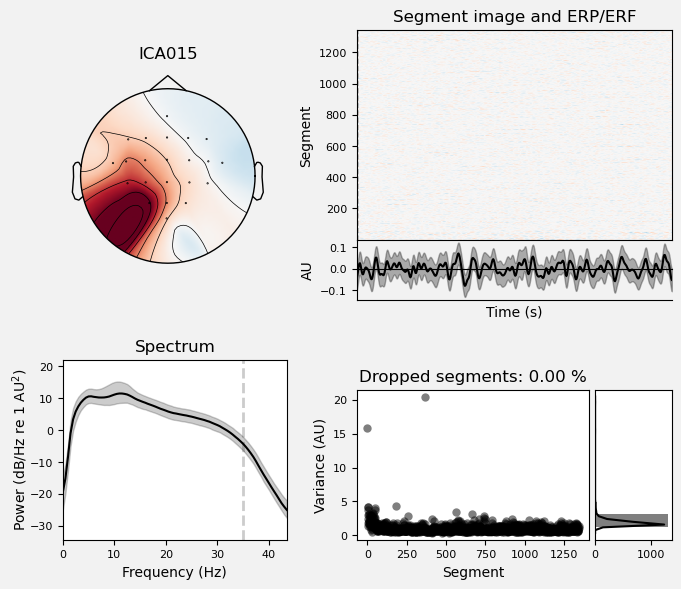

In [12]:
_ = ica.plot_properties(raw, picks=[0, 3, 6, 12, 15])

In [ ]:
raw_clean = apply_ica(ica, raw, [0, 3, 6, 12, 15])

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 5 ICA components
    Projecting back using 22 PCA components


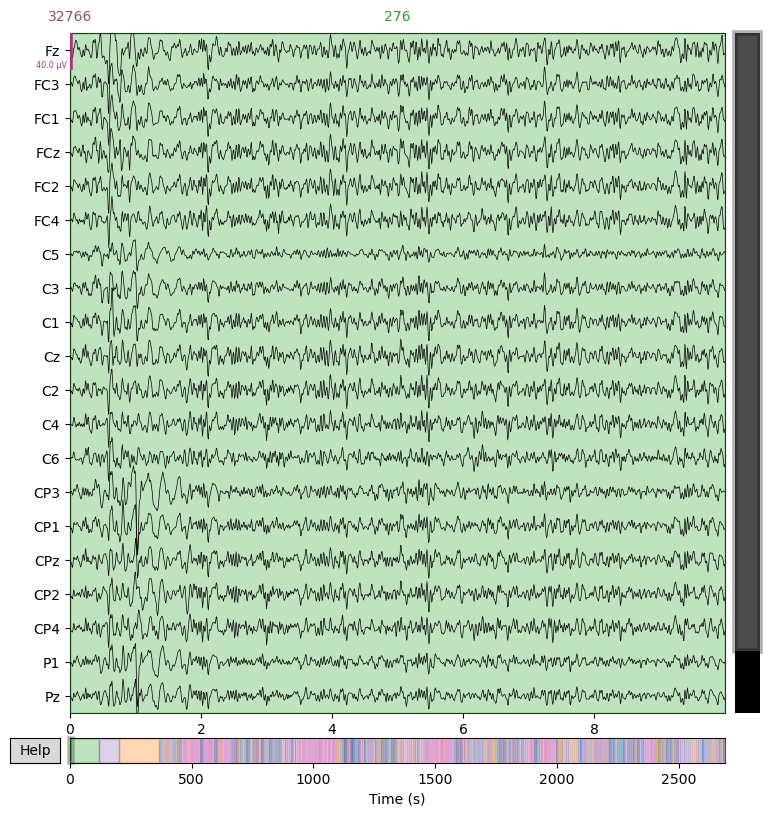

In [14]:
_ = raw_clean.plot()

# Epoching + Creating 4D Tensor

In [15]:
events, event_id = get_motor_events(raw_clean)
raw_epochs = epoch_raw(raw_clean, events, event_id)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 876 original time points ...
0 bad epochs dropped


In [16]:
power, labels = compute_tfr(raw_epochs)

In [17]:
final_tensor = log_normalize(power)

# Spectogram Visualization

*NOTE: This is one example spectogram that gets fed into the CNN*

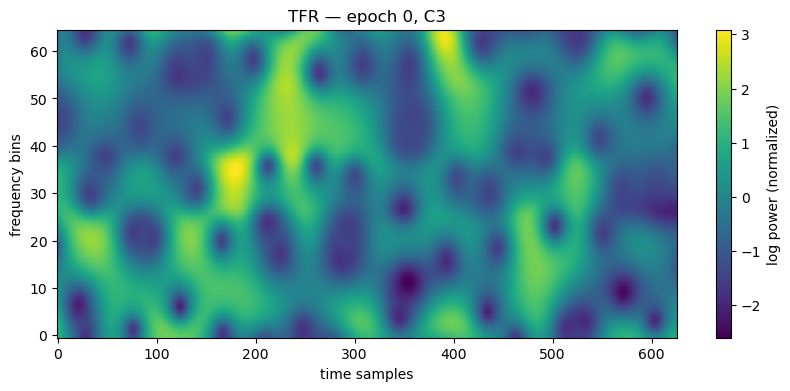

In [19]:
epoch_idx = 0
channel_idx = 7

# final_tensor shape is [n_epochs, 22, n_freqs, n_times]
# now -> shape [n_freqs, n_times]
tfr_slice = final_tensor[epoch_idx, channel_idx, :, :] 

plt.figure(figsize=(10, 4))
plt.imshow(tfr_slice, aspect='auto', origin='lower')
plt.colorbar(label='log power (normalized)')
plt.xlabel('time samples')
plt.ylabel('frequency bins')
plt.title(f'TFR — epoch {epoch_idx}, C3')
plt.show()